In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/content/drive/MyDrive/sample data of blood group types'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/content/drive/MyDrive/sample data of blood group types/A-/cluster_1_3806.BMP
/content/drive/MyDrive/sample data of blood group types/A-/cluster_1_1943.BMP
/content/drive/MyDrive/sample data of blood group types/A-/cluster_1_2768.BMP
/content/drive/MyDrive/sample data of blood group types/A-/cluster_1_4025.BMP
/content/drive/MyDrive/sample data of blood group types/A-/cluster_1_1314.BMP
/content/drive/MyDrive/sample data of blood group types/A-/cluster_1_3467.BMP
/content/drive/MyDrive/sample data of blood group types/A-/cluster_1_2497.BMP
/content/drive/MyDrive/sample data of blood group types/A-/cluster_1_1909.BMP
/content/drive/MyDrive/sample data of blood group types/A-/cluster_1_1455.BMP
/content/drive/MyDrive/sample data of blood group types/A-/cluster_1_1806.BMP
/content/drive/MyDrive/sample data of blood group types/A-/cluster_1_1891.BMP
/content/drive/MyDrive/sample data of blood group types/A-/cluster_1_1814.BMP
/content/driv

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image dimensions
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 5

# Directory paths
train_dir = '/content/drive/MyDrive/sample data of blood group types'

# Data augmentation and preprocessing for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Use 20% of the data for validation
)

# Train generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Validation generator
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Low accuracy model with Input layer
def create_low_accuracy_model():
    model = tf.keras.models.Sequential([
        tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Create the low accuracy model
low_acc_model = create_low_accuracy_model()

# Train the low accuracy model
history_low_acc = low_acc_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

# Evaluate the low accuracy model
low_acc_eval = low_acc_model.evaluate(validation_generator)
print(f"Low Accuracy Model - Loss: {low_acc_eval[0]}, Accuracy: {low_acc_eval[1]}")

Found 4805 images belonging to 8 classes.
Found 1197 images belonging to 8 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 2288s 2s/step - accuracy: 0.5261 - loss: 1.3005 - val_accuracy: 0.8192 - val_loss: 0.4290
Epoch 2/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 155s 145ms/step - accuracy: 0.8648 - loss: 0.3601 - val_accuracy: 0.7916 - val_loss: 0.6236
Epoch 3/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 103s 104ms/step - accuracy: 0.9201 - loss: 0.2125 - val_accuracy: 0.8201 - val_loss: 0.5135
Epoch 4/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 140s 145ms/step - accuracy: 0.9705 - loss: 0.0789 - val_accuracy: 0.8544 - val_loss: 0.4133
Epoch 5/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 142s 145ms/step - accuracy: 0.9853 - loss: 0.0495 - val_accuracy: 0.7808 - val_loss: 0.7686
Epoch 6/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 101s 103ms/step - accuracy: 0.9833 - loss: 0.0391 - val_accuracy: 0.8603 - val_loss: 0.4339
Epoch 7/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 99s 103ms/step - accuracy: 0.9786 - loss: 0.0662 - val_accuracy: 0.8000 - val_loss: 0.7301
Epoch 8/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 142s 103ms/step - accuracy: 0.9863 - lo

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image dimensions
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32

# Directory paths (adjust as needed)
train_dir = '/content/drive/MyDrive/dataset_blood_group'

# Data augmentation and preprocessing for training
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0,1]
    validation_split=0.2  # Use 20% of the data for validation
)

# Train generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'  # Training data subset
)

# Validation generator
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'  # Validation data subset
)

# High accuracy model: Deep CNN
def create_high_accuracy_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.5),  # Regularization to prevent overfitting
        tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')
    ])

    # Compile the model
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Create the model
high_acc_model = create_high_accuracy_model()

# Train the model
history_high_acc = high_acc_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=100,  # Adjust the number of epochs based on your preference
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

# Evaluate the model on validation data
high_acc_eval = high_acc_model.evaluate(validation_generator)
print(f"High Accuracy Model - Loss: {high_acc_eval[0]}, Accuracy: {high_acc_eval[1]}")

Found 4756 images belonging to 8 classes.
Found 1186 images belonging to 8 classes.
Epoch 1/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 70s 450ms/step - accuracy: 0.2957 - loss: 1.8022 - val_accuracy: 0.7686 - val_loss: 0.5885
Epoch 2/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.8125 - loss: 0.5591 - val_accuracy: 0.7711 - val_loss: 0.5910
Epoch 3/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 83s 506ms/step - accuracy: 0.7646 - loss: 0.6301 - val_accuracy: 0.8150 - val_loss: 0.4834
Epoch 4/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.7188 - loss: 0.5935 - val_accuracy: 0.8201 - val_loss: 0.4865
Epoch 5/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 69s 467ms/step - accuracy: 0.8180 - loss: 0.4780 - val_accuracy: 0.8209 - val_loss: 0.4578
Epoch 6/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.7500 - loss: 0.4531 - val_accuracy: 0.7652 - val_loss: 0.6605
Epoch 7/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 64s 425ms/step - accuracy: 0.8483 - loss: 0.4004 - val_accuracy: 0.8302 - val_loss: 0.44

In [ ]:
high_acc_model.save("one_HIGH_accuracy_blood_group_model11.keras")
print("High accuracy model saved successfully!")



High accuracy model saved successfully!


In [ ]:
model_save_path = "/content/drive/MyDrive/one_HIGH_accuracy_blood_group_model11.keras"


In [ ]:
model_save_path = "/content/drive/MyDrive/My_model_blood_group_model.keras"
high_acc_model.save(model_save_path)
print(f"Model saved successfully at {model_save_path}")


Model saved successfully at /content/drive/MyDrive/My_model_blood_group_model.keras


In [ ]:
history_high_acc

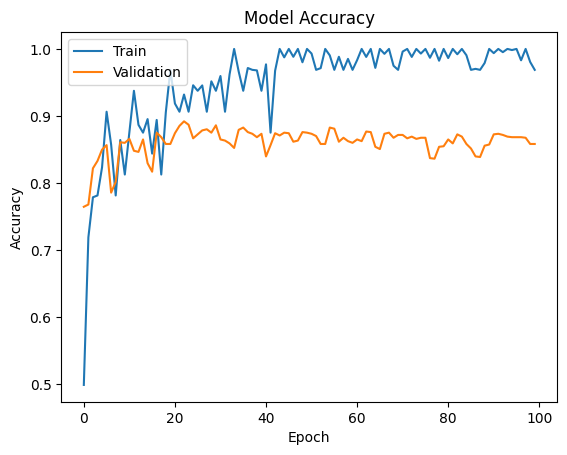

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
def plot_accuracy(history):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

# Call the function to display the accuracy graph
plot_accuracy(history_high_acc)

37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step


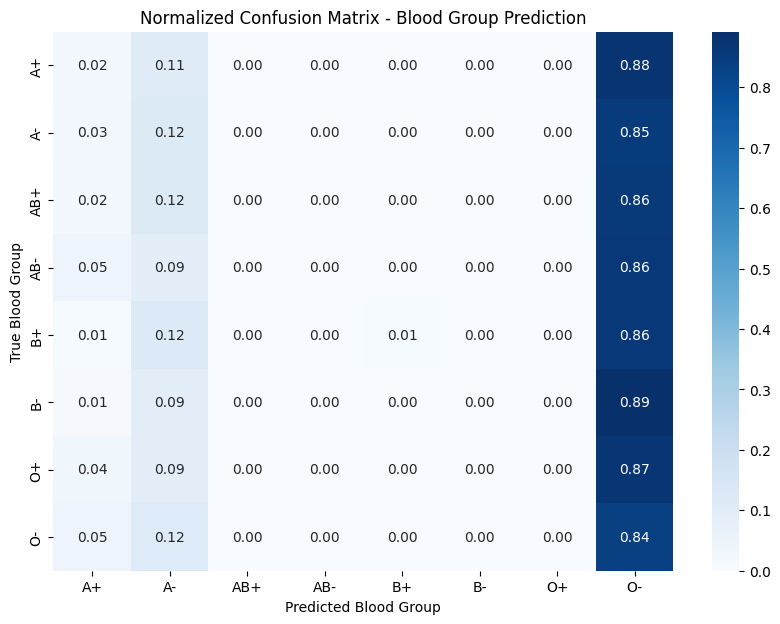

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Predict on the validation set
Y_pred = high_acc_model.predict(validation_generator, steps=validation_generator.samples // BATCH_SIZE, verbose=1)

# Step 2: Convert predictions to class labels
y_pred = np.argmax(Y_pred, axis=1)  # Convert probabilities to class indices

# Step 3: Get the true labels
y_true = validation_generator.classes

# Flatten both y_true and y_pred to ensure they have the same shape
y_true = y_true[:len(y_pred)]  # In case there are extra samples in validation

# Ensure the shapes are now correct and match
assert y_true.shape[0] == y_pred.shape[0], "Mismatch between true and predicted labels"

# Step 4: Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Step 5: Normalize the confusion matrix (optional, if you'd like to see percentages instead of counts)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Step 6: Plot the confusion matrix using a heatmap
plt.figure(figsize=(10,7))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

# Step 7: Add labels and title for better visualization
plt.xlabel('Predicted Blood Group')
plt.ylabel('True Blood Group')
plt.title('Normalized Confusion Matrix - Blood Group Prediction')

# Show the plot
plt.show()


In [ ]:
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)


38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 244ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

conf_matrix = confusion_matrix(y_test, predicted_labels)
print("Confusion Matrix:")
print(conf_matrix)

# Define blood_groups here
blood_groups = ['A-', 'A+', 'AB-', 'AB+', 'B-', 'B+', 'O-', 'O+']

# Optional: Classification Report
print("\nClassification Report:")
print(classification_report(y_test, predicted_labels, target_names=blood_groups))

Confusion Matrix:
[[117   0   7   0   0   0   9   2]
 [  0 195   4   0   2   2  13   0]
 [  1   1 130   0   2   0   4   0]
 [  0  11   1 108   4   3   2   3]
 [  0   7   2   3 113   4   0   0]
 [  0   8   0   1   2 129   0   0]
 [  2   4   6   0   0   0 160   0]
 [  4   1  11   0   2   0  12 108]]

Classification Report:
              precision    recall  f1-score   support

          A-       0.94      0.87      0.90       135
          A+       0.86      0.90      0.88       216
         AB-       0.81      0.94      0.87       138
         AB+       0.96      0.82      0.89       132
          B-       0.90      0.88      0.89       129
          B+       0.93      0.92      0.93       140
          O-       0.80      0.93      0.86       172
          O+       0.96      0.78      0.86       138

    accuracy                           0.88      1200
   macro avg       0.90      0.88      0.88      1200
weighted avg       0.89      0.88      0.88      1200



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os # Import the os module

def gabor_filter(img, ksize=5, sigma=4.0, theta=np.pi/4, lambd=10.0, gamma=0.5, psi=0):
    gabor_kernel = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, psi, ktype=cv2.CV_32F)
    filtered_img = cv2.filter2D(img, cv2.CV_8UC3, gabor_kernel)
    return filtered_img

# Load a sample fingerprint image
# Check if the image file exists
image_path = '/content/drive/MyDrive/sample data of blood group types'  # Update with actual image path

if os.path.exists(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Check if the image was loaded successfully
    if img is not None:
        filtered_img = gabor_filter(img)

        # Show the original and filtered image
        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1), plt.imshow(img, cmap='gray'), plt.title('Original')
        plt.subplot(1,2,2), plt.imshow(filtered_img, cmap='gray'), plt.title('Gabor Filtered')
        plt.show()
    else:
        print(f"Error: Could not load image from {image_path}")
else:
    print(f"Error: Image file not found at {image_path}")

Error: Could not load image from /content/drive/MyDrive/sample data of blood group types


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence
import cv2
import numpy as np

class GaborImageDataGenerator(Sequence):
    def __init__(self, generator):
        self.generator = generator

    def __len__(self):
        return len(self.generator)

    def __getitem__(self, idx):
        batch_x, batch_y = self.generator[idx]
        batch_x = np.array([gabor_filter(img) for img in batch_x])
        return batch_x, batch_y

# Use ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(64, 64), batch_size=32, class_mode='categorical', subset='training')

# Apply Gabor filtering
train_generator = GaborImageDataGenerator(train_generator)


Found 4805 images belonging to 8 classes.


In [ ]:
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/My_model_blood_group_model.keras"
model = load_model(model_path)
print("Model loaded successfully!")


Model loaded successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import tensorflow as tf
import os

# Load the pre-trained model
model_path = "/content/drive/MyDrive/My_model_blood_group_model.keras"
high_acc_model = tf.keras.models.load_model(model_path)

# Define image dimensions (Ensure this matches the model input size)
IMG_HEIGHT = 64
IMG_WIDTH = 64

# Function to preprocess an image and make a prediction
def predict_blood_group(image_path):
    # Load and preprocess the image
    img = image.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions for model input
    img_array /= 255.0  # Normalize pixel values to [0,1]

    # Make a prediction
    predictions = high_acc_model.predict(img_array)

    # Get the predicted class index
    predicted_class = np.argmax(predictions)

    # Get the class label mapping
    class_labels = {
        0: "A+",
        1: "A-",
        2: "AB+",
        3: "AB-",
        4: "B+",
        5: "B-",
        6: "O+",
        7: "O-"
    }

    # Get the predicted blood group
    predicted_blood_group = class_labels.get(predicted_class, "Unknown")
    print(f"The predicted blood group is: {predicted_blood_group}")

# Example usage:
image_path = "///content/drive/MyDrive/Testing Images/Testing/B-/cluster_3_834.BMP"  # Update with actual image path
predict_blood_group(image_path)


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import tensorflow as tf
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the pre-trained model
model_path = "/content/drive/MyDrive/My_model_blood_group_model.keras"
high_acc_model = tf.keras.models.load_model(model_path)

# Define image dimensions (Ensure this matches the model input size)
IMG_HEIGHT = 64
IMG_WIDTH = 64

# Define blood group labels
blood_groups = ['A-', 'A+', 'AB-', 'AB+', 'B-', 'B+', 'O-', 'O+']

# Function to preprocess an image and make a prediction
def predict_blood_group(image_path):
    img = image.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0
    predictions = high_acc_model.predict(img_array)
    predicted_class = np.argmax(predictions)
    return predicted_class  # Return the predicted class index

# Path to your testing images directory
test_dir = "/content/drive/MyDrive/sample data of blood group types"  # Update with your test data path

# Get a list of all image files in the test directory and their true labels
image_paths = []
true_labels = []
for blood_group in blood_groups:
    blood_group_dir = os.path.join(test_dir, blood_group)
    for filename in os.listdir(blood_group_dir):
        image_paths.append(os.path.join(blood_group_dir, filename))
        true_labels.append(blood_groups.index(blood_group))  # Get index of blood group

# Make predictions for all test images
predicted_labels = []
for image_path in image_paths:
    predicted_labels.append(predict_blood_group(image_path))

# Generate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Normalize confusion matrix (optional)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=blood_groups, yticklabels=blood_groups)
plt.xlabel('Predicted Blood Group')
plt.ylabel('True Blood Group')
plt.title('Normalized Confusion Matrix - Blood Group Prediction')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━